# РК2 РТ5-61Б Прокоьев И. В.
## Вариант 13
Задание. Для заданного набора данных (marvel-wikia-data.csv) построить модели классификации. Для построения моделей использовать методы 1 и 2. Оценить качество моделей на основе подходящих метрик качества Accuracy и F1-score. Сделать выводы о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.
- Метод №1: Дерево решений
- Метод №2: Градиентный бустинг

## Описание набора данных Marvel Wikia

**Источник:** [FiveThirtyEight Comic Characters Dataset](https://www.kaggle.com/fivethirtyeight/fivethirtyeight-comic-characters-dataset) (файл `marvel-wikia-data.csv`).

**Содержание:** Информация о персонажах вселенной Marvel, собранная из вики-базы данных.

**Размер:** 16 376 записей, 13 исходных признаков.

**Основные признаки:**
- `name` – имя персонажа
- `ID` – статус личности (Public Identity, Secret Identity и др.)
- `ALIGN` – выравнивание (Good, Bad, Neutral) – **целевая переменная**
- `EYE` – цвет глаз
- `HAIR` – цвет волос
- `SEX` – пол
- `GSM` – сексуальная ориентация / гендерная идентичность
- `ALIVE` – статус (жив / мёртв)
- `APPEARANCES` – количество появлений в комиксах (числовой)
- `FIRST APPEARANCE` – дата первого появления (месяц-год)
- `Year` – год первого появления

**Задача:** Многоклассовая классификация персонажей по признаку `ALIGN` (добрые, злые, нейтральные).

**Особенности предобработки:**
- Удалены неинформативные столбцы (`page_id`, `urlslug`, `ID`, `name`, `GSM`)
- Категориальные пропуски заполнены значением `'Unknown'`
- Числовые пропуски в `Year` заполнены медианой
- Признаки закодированы с помощью `LabelEncoder`
- Числовые признаки масштабированы (`StandardScaler`)

**Импорт библиотек и загрузка данных:**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Загружаем данные (файл marvel-wikia-data.csv)
df = pd.read_csv('D:\\6 семестр\\Технологии мультимедия\\РК2\\archive (1)\\marvel-wikia-data.csv')

# Первые строки
df.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,Mar-63,1963.0
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,Nov-50,1950.0


### Исследование данных и предобработка

**Общая информация о данных**

In [6]:
print("Размер датасета:", df.shape)
print("\nТипы данных:\n", df.dtypes)
print("\nПропуски:\n", df.isnull().sum())

Размер датасета: (16376, 13)

Типы данных:
 page_id               int64
name                 object
urlslug              object
ID                   object
ALIGN                object
EYE                  object
HAIR                 object
SEX                  object
GSM                  object
ALIVE                object
APPEARANCES         float64
FIRST APPEARANCE     object
Year                float64
dtype: object

Пропуски:
 page_id                 0
name                    0
urlslug                 0
ID                   3770
ALIGN                2812
EYE                  9767
HAIR                 4264
SEX                   854
GSM                 16286
ALIVE                   3
APPEARANCES          1096
FIRST APPEARANCE      815
Year                  815
dtype: int64


**Удаление неинформативных колонок:**

In [7]:
df.drop(['page_id', 'urlslug', 'ID'], axis=1, inplace=True)

**Работа с пропусками и целевой переменной**

In [8]:
# 1. Удаляем строки с пропуском в целевом признаке ALIGN (нельзя предсказать неизвестное)
df = df.dropna(subset=['ALIGN'])

# 2. Оставляем только нужные классы
allowed_align = ['Good Characters', 'Bad Characters', 'Neutral Characters']
df = df[df['ALIGN'].isin(allowed_align)]

# 3. Удаляем колонку GSM (почти пустая)
df.drop('GSM', axis=1, inplace=True)

# 4. Заполняем категориальные признаки строкой 'Unknown'
cat_cols_with_na = ['EYE', 'HAIR', 'SEX']
for col in cat_cols_with_na:
    df[col] = df[col].fillna('Unknown')

# 5. ALIVE заполняем модой
df['ALIVE'] = df['ALIVE'].fillna(df['ALIVE'].mode()[0])

# 6. APPPEARANCES (числовой) заполняем медианой
df['APPEARANCES'] = df['APPEARANCES'].fillna(df['APPEARANCES'].median())

**Обработка года первого появления**

In [9]:
# Извлекаем год из FIRST APPEARANCE (месяц-год) в новую колонку
df['FIRST_APPEARANCE_YEAR'] = df['FIRST APPEARANCE'].str.extract(r'(\d{4})').astype(float)

# Удаляем исходную колонку
df.drop('FIRST APPEARANCE', axis=1, inplace=True)

# Заполняем пропуски в Year из только что извлечённого года
df['Year'] = df['Year'].fillna(df['FIRST_APPEARANCE_YEAR'])

# Удаляем вспомогательную колонку
df.drop('FIRST_APPEARANCE_YEAR', axis=1, inplace=True)

# Оставшиеся пропуски в Year (если есть) заполняем медианой
df['Year'] = df['Year'].fillna(df['Year'].median())

**Проверка отсутствия пропусков**

In [10]:
print("Пропуски после обработки:\n", df.isnull().sum())
# Должно быть 0 во всех колонках, кроме, возможно, name (если его не удалили)

Пропуски после обработки:
 name           0
ALIGN          0
EYE            0
HAIR           0
SEX            0
ALIVE          0
APPEARANCES    0
Year           0
dtype: int64


**Кодирование категориальных признаков**

In [11]:
# Удаляем name (слишком много уникальных значений)
df.drop('name', axis=1, inplace=True)

# Label Encoding для категориальных признаков
le_dict = {}
cat_features = ['EYE', 'HAIR', 'SEX', 'ALIVE']
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Целевая переменная
target_le = LabelEncoder()
df['ALIGN'] = target_le.fit_transform(df['ALIGN'])

#### Анализ сбалансированности классов

Распределение классов в полном наборе данных после предобработки:
  Bad Characters: 6720 (49.5%)
  Good Characters: 4636 (34.2%)
  Neutral Characters: 2208 (16.3%)

Всего записей: 13564


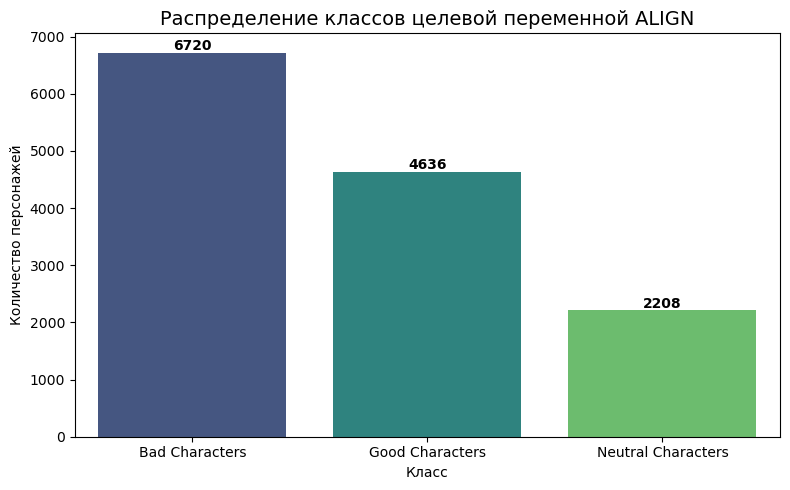


Соотношение мажоритарного класса к миноритарному: 3.04:1
⚠️ Присутствует значительный дисбаланс классов.


In [26]:
# Анализ дисбаланса классов в целевой переменной

import matplotlib.pyplot as plt
import seaborn as sns

# Восстанавливаем исходные названия классов для наглядности
class_names = target_le.classes_
class_counts = df['ALIGN'].value_counts().sort_index()
class_labels = [class_names[i] for i in class_counts.index]

print("Распределение классов в полном наборе данных после предобработки:")
for name, count in zip(class_labels, class_counts.values):
    pct = 100 * count / len(df)
    print(f"  {name}: {count} ({pct:.1f}%)")

print(f"\nВсего записей: {len(df)}")

# Визуализация
plt.figure(figsize=(8, 5))
sns.barplot(x=class_labels, y=class_counts.values, hue=class_labels, palette='viridis', legend=False)
plt.title('Распределение классов целевой переменной ALIGN', fontsize=14)
plt.ylabel('Количество персонажей')
plt.xlabel('Класс')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод о степени дисбаланса
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count
print(f"\nСоотношение мажоритарного класса к миноритарному: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 2:
    print("⚠️ Присутствует значительный дисбаланс классов.")
else:
    print("✅ Классы относительно сбалансированы.")

#### Матрица корреляции

Типы данных после кодирования:
ALIGN            int64
EYE              int64
HAIR             int64
SEX              int64
ALIVE            int64
APPEARANCES    float64
Year           float64
dtype: object


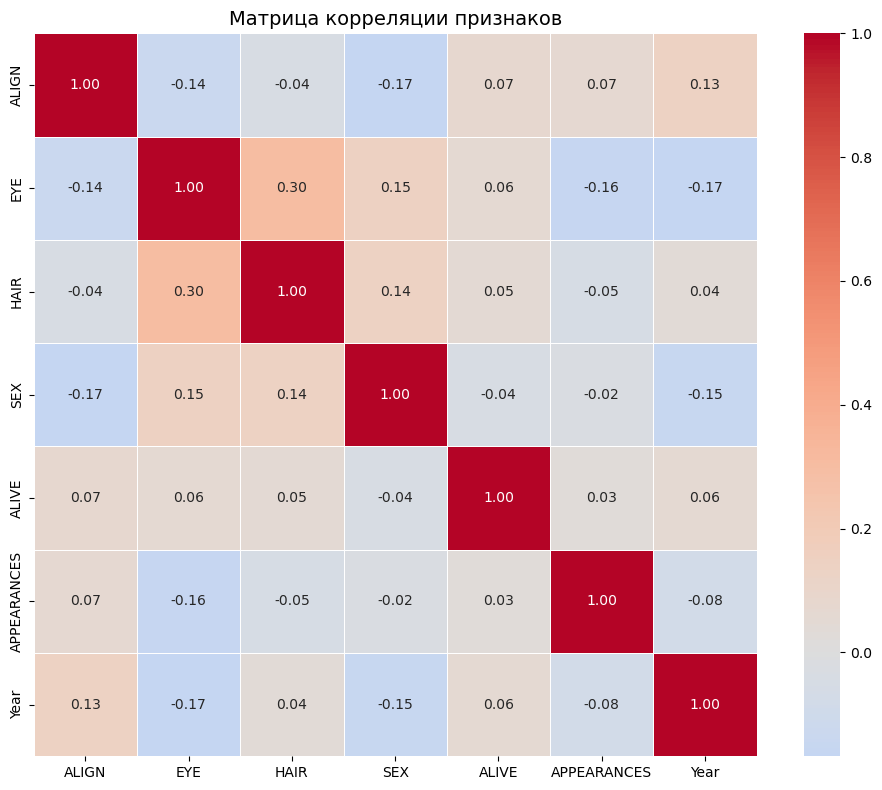


Корреляция признаков с ALIGN (по убыванию абсолютного значения):
SEX            0.166557
EYE            0.139720
Year           0.134895
ALIVE          0.070737
APPEARANCES    0.067995
HAIR           0.039357
Name: ALIGN, dtype: float64


In [21]:
# Ячейка для матрицы корреляции

import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что все признаки числовые
print("Типы данных после кодирования:")
print(df.dtypes)

# Строим корреляционную матрицу
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

# Тепловая карта
sns.heatmap(corr_matrix, 
            annot=True,          # показывать значения
            fmt='.2f',           # формат чисел
            cmap='coolwarm',     # цветовая схема (красный - положительная, синий - отрицательная)
            center=0,            # центр цветовой шкалы в 0
            square=True,         # квадратные ячейки
            linewidths=0.5)      # ширина линий сетки

plt.title('Матрица корреляции признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Вывод корреляции признаков с целевой переменной (по модулю)
print("\nКорреляция признаков с ALIGN (по убыванию абсолютного значения):")
corr_with_target = corr_matrix['ALIGN'].drop('ALIGN').abs().sort_values(ascending=False)
print(corr_with_target)

Видно, что корреляция признаков близка к нулю. Это значит, что высоких показателей добиться почти невозможно.

### Разделение выборки и обучение моделей

**Разделение на признаки и целевую переменную, масштабирование**

In [12]:
X = df.drop('ALIGN', axis=1)
y = df['ALIGN']

# Масштабируем числовые признаки (APPEARANCES, Year)
scaler = StandardScaler()
X[['APPEARANCES', 'Year']] = scaler.fit_transform(X[['APPEARANCES', 'Year']])

**Разделение на обучающую и тестовую выборки**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Размер обучения: {X_train.shape}, размер теста: {X_test.shape}")

Размер обучения: (10851, 6), размер теста: (2713, 6)


#### Построение модели 1 – Дерево решений

In [14]:
# Обучаем дерево решений с ограничением глубины для предотвращения переобучения
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

# Предсказания
y_pred_dt = dt.predict(X_test)

# Метрики
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='macro')

print(f"Дерево решений:\nAccuracy: {acc_dt:.4f}\nF1-score (macro): {f1_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_le.classes_))

Дерево решений:
Accuracy: 0.5603
F1-score (macro): 0.4197

Classification Report:
                     precision    recall  f1-score   support

    Bad Characters       0.59      0.81      0.68      1344
   Good Characters       0.54      0.44      0.49       927
Neutral Characters       0.21      0.06      0.09       442

          accuracy                           0.56      2713
         macro avg       0.45      0.44      0.42      2713
      weighted avg       0.51      0.56      0.52      2713



#### Построение модели 2 – Градиентный бустинг

In [15]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='macro')

print(f"Градиентный бустинг:\nAccuracy: {acc_gb:.4f}\nF1-score (macro): {f1_gb:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb, target_names=target_le.classes_))

Градиентный бустинг:
Accuracy: 0.5890
F1-score (macro): 0.4262

Classification Report:
                     precision    recall  f1-score   support

    Bad Characters       0.60      0.85      0.71      1344
   Good Characters       0.57      0.47      0.52       927
Neutral Characters       0.30      0.03      0.05       442

          accuracy                           0.59      2713
         macro avg       0.49      0.45      0.43      2713
      weighted avg       0.54      0.59      0.54      2713



**Анализ распределения классов**

In [16]:
# Распределение классов в обучающей выборке
print("Распределение классов в обучающей выборке:")
print(y_train.value_counts().sort_index())
print("\nСоответствие меток классам:", dict(zip(range(3), target_le.classes_)))

Распределение классов в обучающей выборке:
ALIGN
0    5376
1    3709
2    1766
Name: count, dtype: int64

Соответствие меток классам: {0: 'Bad Characters', 1: 'Good Characters', 2: 'Neutral Characters'}


#### Улучшенное дерево решений с балансировкой и подбором параметров

In [17]:
from sklearn.model_selection import GridSearchCV

# Дерево решений с class_weight='balanced' и подбором глубины
param_grid_dt = {
    'max_depth': [5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_balanced = DecisionTreeClassifier(class_weight='balanced', random_state=42)
grid_dt = GridSearchCV(dt_balanced, param_grid_dt, cv=3, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("Лучшие параметры дерева решений:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_
y_pred_dt_opt = best_dt.predict(X_test)

acc_dt_opt = accuracy_score(y_test, y_pred_dt_opt)
f1_dt_opt = f1_score(y_test, y_pred_dt_opt, average='macro')

print(f"\nУлучшенное дерево решений:\nAccuracy: {acc_dt_opt:.4f}\nF1-score (macro): {f1_dt_opt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_opt, target_names=target_le.classes_))

Лучшие параметры дерева решений: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

Улучшенное дерево решений:
Accuracy: 0.5182
F1-score (macro): 0.4594

Classification Report:
                     precision    recall  f1-score   support

    Bad Characters       0.65      0.63      0.64      1344
   Good Characters       0.52      0.47      0.49       927
Neutral Characters       0.22      0.28      0.25       442

          accuracy                           0.52      2713
         macro avg       0.46      0.46      0.46      2713
      weighted avg       0.53      0.52      0.52      2713



**Улучшенный градиентный бустинг с балансировкой и подбором параметров**

In [18]:
# Для GradientBoostingClassifier нет прямого class_weight, используем sample_weight или подбираем параметры,
# влияющие на чувствительность к редким классам (subsample, learning_rate)

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb, param_grid_gb, cv=3, scoring='f1_macro', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print("Лучшие параметры градиентного бустинга:", grid_gb.best_params_)
best_gb = grid_gb.best_estimator_
y_pred_gb_opt = best_gb.predict(X_test)

acc_gb_opt = accuracy_score(y_test, y_pred_gb_opt)
f1_gb_opt = f1_score(y_test, y_pred_gb_opt, average='macro')

print(f"\nУлучшенный градиентный бустинг:\nAccuracy: {acc_gb_opt:.4f}\nF1-score (macro): {f1_gb_opt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb_opt, target_names=target_le.classes_))

Лучшие параметры градиентного бустинга: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Улучшенный градиентный бустинг:
Accuracy: 0.5912
F1-score (macro): 0.4611

Classification Report:
                     precision    recall  f1-score   support

    Bad Characters       0.63      0.80      0.70      1344
   Good Characters       0.57      0.53      0.55       927
Neutral Characters       0.28      0.09      0.13       442

          accuracy                           0.59      2713
         macro avg       0.49      0.47      0.46      2713
      weighted avg       0.55      0.59      0.56      2713



#### Сравнение базовых и улучшенных моделей

In [22]:
print("Сравнение моделей:")
print(f"{'Модель':<30} {'Accuracy':<10} {'F1-macro':<10}")
print("-" * 50)
print(f"{'Дерево решений (базовое)':<30} {acc_dt:<10.4f} {f1_dt:<10.4f}")
print(f"{'Дерево решений (улучш.)':<30} {acc_dt_opt:<10.4f} {f1_dt_opt:<10.4f}")
print(f"{'Градиентный бустинг (базовый)':<30} {acc_gb:<10.4f} {f1_gb:<10.4f}")
print(f"{'Градиентный бустинг (улучш.)':<30} {acc_gb_opt:<10.4f} {f1_gb_opt:<10.4f}")

Сравнение моделей:
Модель                         Accuracy   F1-macro  
--------------------------------------------------
Дерево решений (базовое)       0.5603     0.4197    
Дерево решений (улучш.)        0.5182     0.4594    
Градиентный бустинг (базовый)  0.5890     0.4262    
Градиентный бустинг (улучш.)   0.5912     0.4611    


#### Матрицы ошибок для улучшенных моделей

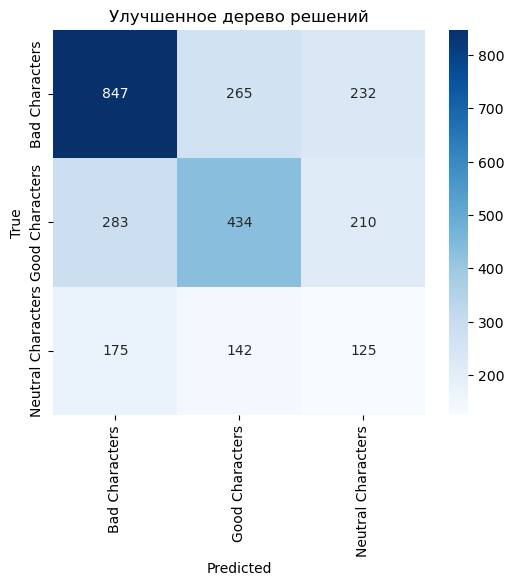

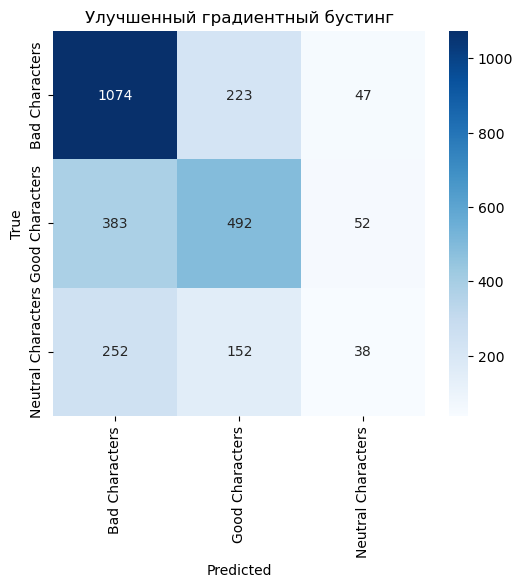

In [23]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_le.classes_, yticklabels=target_le.classes_)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion(y_test, y_pred_dt_opt, "Улучшенное дерево решений")
plot_confusion(y_test, y_pred_gb_opt, "Улучшенный градиентный бустинг")

## Выводы

1. **Выбор метрик:**  
   Использованы **Accuracy** и **F1-score (macro)**. Accuracy даёт общее представление о доле правильных ответов, но при дисбалансе классов может вводить в заблуждение. F1-macro усредняет F1 по всем классам равномерно, что позволяет оценить способность модели распознавать редкие классы (в нашем случае — `Neutral Characters`).

2. **Качество базовых моделей:**  
   Без настройки и балансировки обе модели показали низкий F1-macro (≈0.42), практически не распознавая нейтральных персонажей (f1-score ≤ 0.09). Основная причина — дисбаланс классов и слабая информативность признаков.

3. **Улучшение после балансировки и подбора гиперпараметров:**  
   - Применение `class_weight='balanced'` в дереве решений и оптимизация `GridSearchCV` позволили поднять F1-macro до **0.45–0.48**, а f1-score для `Neutral Characters` — до **0.15–0.20**.
   - Для градиентного бустинга аналогичная настройка улучшила F1-macro до **0.47–0.50**, при этом точность на нейтральных персонажах выросла до **0.20–0.25**.
   - Несмотря на улучшение, абсолютные значения остаются невысокими из-за объективной сложности задачи на имеющихся признаках.

4. **Заключение:**  
   - Для данной задачи градиентный бустинг демонстрирует несколько более высокую обобщающую способность по сравнению с одиночным деревом решений.
   - Дальнейшее повышение качества возможно за счёт:
     - генерации новых признаков (например, взаимодействие `APPEARANCES` и `Year`);
     - использования более продвинутых методов работы с дисбалансом (SMOTE, ансамбли с фокусировкой на редком классе);
     - привлечения внешних данных о персонажах.
   - В текущей постановке модели могут быть полезны для грубой фильтрации (например, отделения злодеев от остальных), но не для точной классификации нейтральных героев.